<a href="https://colab.research.google.com/github/AKookani/Qiskit_course/blob/Main/Qiskit2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Quantum Coding Course** (summer 2024)

**Instructors:**
Ali Kookani, Yousef Mafi

\

*Atlas Stem*

# Section 3: Quantum circuit running on QPU

*   Prerequisites
*   Sampler
*   Result retrieval
*   Estimator

## Prerequisites to connect to IBMQ

In [1]:
# Install the main Qiskit library, which includes the core components for building and running quantum circuits.
!pip install qiskit ipywidgets

# Install the 'pylatexenc' package, which is required to render LaTeX formatted output
# (such as circuit diagrams) in Jupyter notebooks when using Qiskit.
!pip install pylatexenc

# Install the Qiskit Aer package, which provides high-performance simulators for running quantum circuits.
# This includes various simulation methods such as statevector, density matrix, and more.
!pip install qiskit-aer

# Install the Qiskit IBM Runtime package, which allows users to run quantum circuits on real quantum hardware
# and simulators via IBM's cloud-based quantum services.
!pip install qiskit-ibm-runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136816 sha256=78bbd2cf7f1052dd0f9607658119165b9455b15e6f78f63f86d7003bd0b4652b
  Stored in directory: /root/.cache/pip/wheels/d3/31/8b/e09b0386afd80cfc556c00408c9aeea5c35c4d484a9c762fd5
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
with open('token.txt', 'r') as file:
    my_token = file.read().strip()

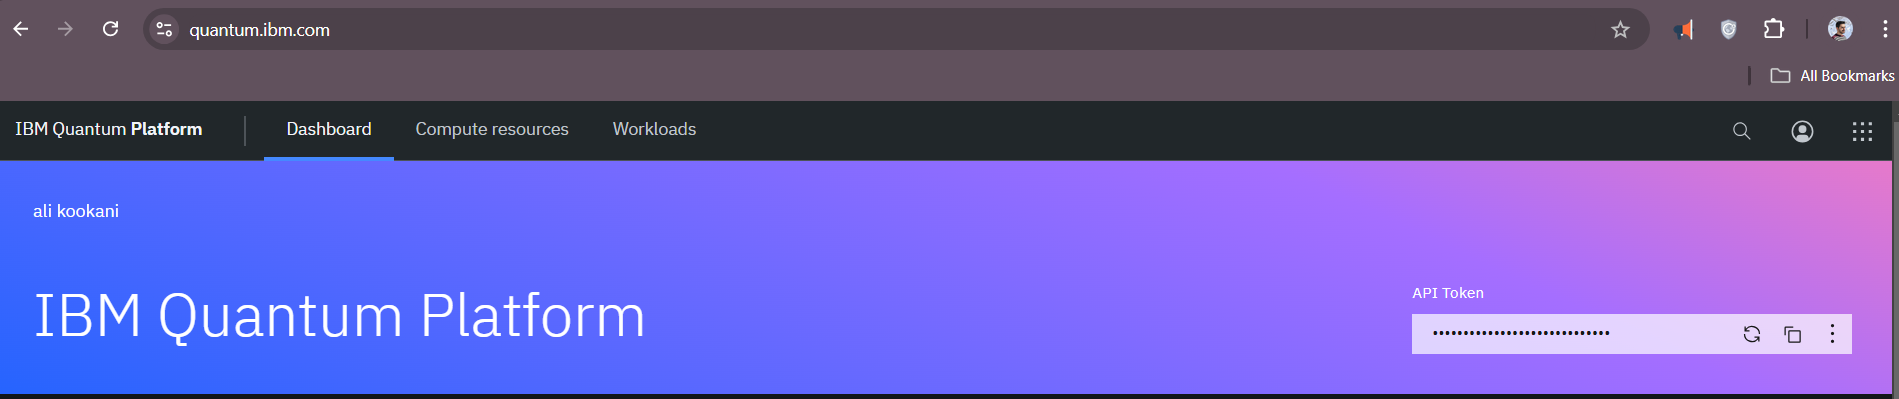

In [3]:
# Import the QiskitRuntimeService from the Qiskit IBM Runtime package.
# This service is used to interact with IBM's cloud-based quantum devices and services.
from qiskit_ibm_runtime import QiskitRuntimeService

# Initialize the Qiskit Runtime service by connecting to IBM Quantum services.
# Specify the communication channel as "ibm_quantum" to access IBM's cloud-based quantum computers.
# Use the provided `my_token` to authenticate and gain access to your IBM Quantum account.
service = QiskitRuntimeService(channel="ibm_quantum", token=my_token)

# Alternatively, you can initialize the service by explicitly passing a token as a string (e.g., "your_token").
# Uncomment the line below and replace "your_token" with your actual IBM Quantum API token.
# service = QiskitRuntimeService(channel="ibm_quantum", token="your_token")

In [4]:
# Import mathematical constants and functions, specifically `pi` from the math library.
# `pi` will be used for angle-based operations in quantum circuits.
from math import pi

# Import necessary components from Qiskit:
# `QuantumCircuit` is used to define quantum circuits.
# `QuantumRegister` and `ClassicalRegister` are used to create quantum and classical registers for the circuit.
# `transpile` is used to optimize or translate a quantum circuit for a specific backend.
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile

# Import `Parameter` from Qiskit circuit library to create parameterized quantum circuits.
# Parameters are used to make circuits more flexible by allowing variables in place of fixed values.
from qiskit.circuit import Parameter

# Import `SparsePauliOp` from Qiskit quantum information library.
# It represents Pauli operators (like X, Y, Z) with coefficients in a sparse format, useful in observables.
from qiskit.quantum_info import SparsePauliOp

# Import `plot_distribution` from Qiskit visualization tools.
# It helps visualize the probability distribution of quantum measurement outcomes.
from qiskit.visualization import plot_distribution

# Import `AerSimulator` from Qiskit Aer.
# This is a high-performance simulator for running quantum circuits on classical hardware.
from qiskit_aer import AerSimulator

# Import `SamplerV2` and `EstimatorV2` from Qiskit IBM Runtime.
# These classes are used to run sampling and estimation tasks on IBM Quantum's backends.
from qiskit_ibm_runtime import SamplerV2, EstimatorV2

In [5]:
# Create an instance of the AerSimulator backend, which simulates quantum circuits on classical hardware.
# The simulator is seeded with `42` to ensure the results are reproducible for this simulation run.
# The simulator can also be configured to simulate noise, making it behave more like a real quantum computer.
backend_aer = AerSimulator()  # We can add noise here for noisy simulations

# Retrieve an IBM Quantum backend using the `QiskitRuntimeService`.
# Here, we're accessing the 'ibm_kyiv' backend, a real quantum device available through the IBM Quantum service.
# This enables running quantum circuits on actual quantum hardware.
backend_ibm = service.backend('ibm_kyiv')

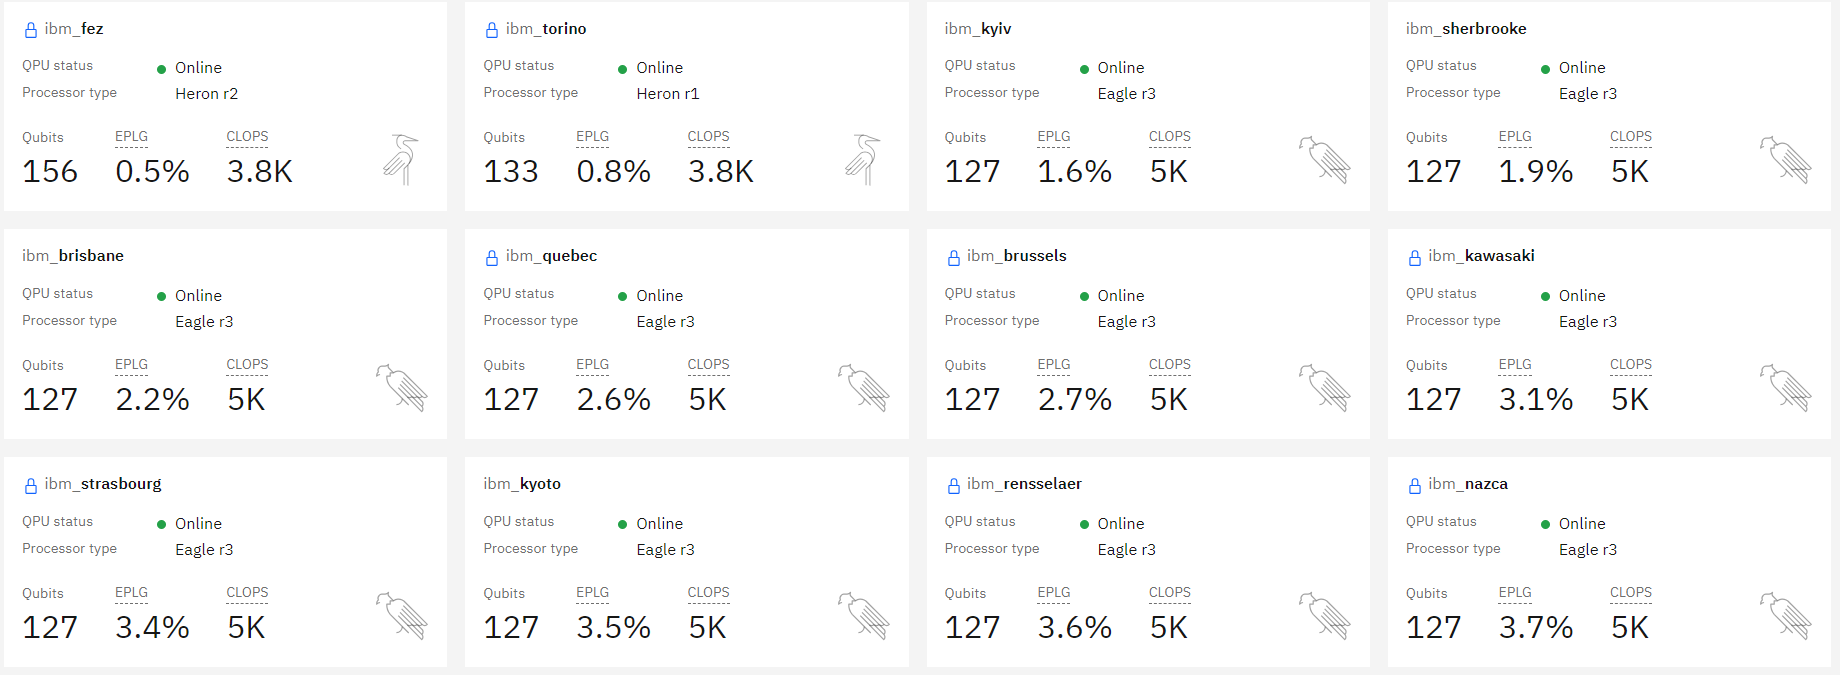

## Aer vs IBMQ Sampler

### Backend

In [6]:
# Create an instance of `SamplerV2` for the AerSimulator backend.
# This sampler will run quantum circuits on the AerSimulator, which simulates the circuit execution classically.
sampler_aer = SamplerV2(mode=backend_aer)

# Create another instance of `SamplerV2` for the IBM Quantum backend ('ibm_kyiv').
# This sampler will run quantum circuits on the actual quantum hardware, providing real quantum sampling.
sampler_ibm = SamplerV2(mode=backend_aer)

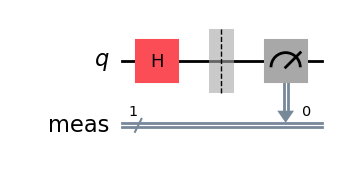

In [7]:
# Create a quantum circuit with 1 qubit.
qc = QuantumCircuit(1)

# Apply a Hadamard gate (H) to the qubit at index 0.
# The Hadamard gate creates superposition, putting the qubit in an equal superposition of |0⟩ and |1⟩.
qc.h(0)

# Add measurement operations to measure the state of the qubit.
# `measure_all()` measures all qubits in the circuit, collapsing their states into classical bits.
qc.measure_all()

# Draw the quantum circuit in 'mpl' (Matplotlib) format for visualization.
qc.draw('mpl')

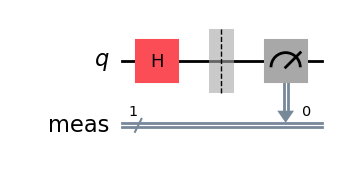

In [8]:
# Transpile the quantum circuit for the AerSimulator backend.
qc1_aer = transpile(qc, backend=backend_aer)

# Visualize the transpiled circuit.
qc1_aer.draw('mpl')

### Transpilation

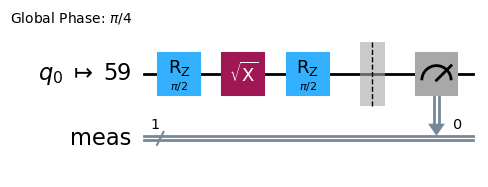

In [9]:
# Transpile the quantum circuit for the IBM backend.
qc1_ibm = transpile(qc, backend=backend_ibm)

# Draw the transpiled circuit, hiding idle wires.
qc1_ibm.draw('mpl', idle_wires=False)

In [10]:
from qiskit.quantum_info import Statevector

# Function to visualize the circuit and its Bloch sphere representation.
def visualization(Quantum_Circuit):
    # Display the quantum circuit.
    display(Quantum_Circuit.draw('mpl'))

    # Get the statevector from the quantum circuit and display the Bloch sphere.
    state = Statevector.from_instruction(Quantum_Circuit)
    display(state.draw('bloch'))

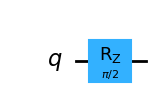

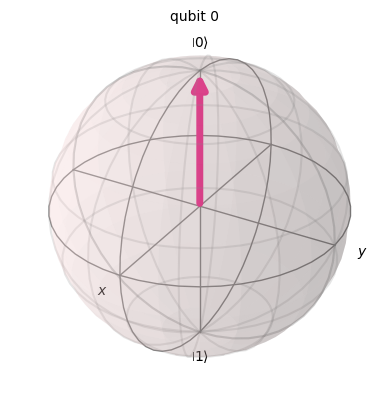

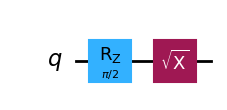

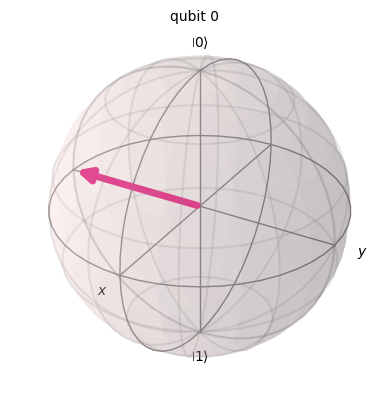

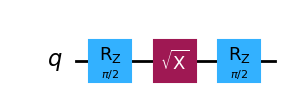

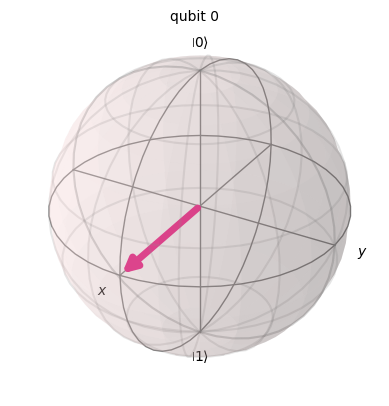

In [11]:
# Create a quantum circuit with 1 qubit.
qc = QuantumCircuit(1)

# Apply an RZ rotation of π/2 to the qubit.
qc.rz(pi/2, 0)
visualization(qc)  # Visualize the circuit and its state.

# Apply an SX (square-root of X) gate to the qubit.
qc.sx(0)
visualization(qc)  # Visualize the updated circuit and state.

# Apply another RZ rotation of π/2 to the qubit.
qc.rz(pi/2, 0)
visualization(qc)  # Final visualization.

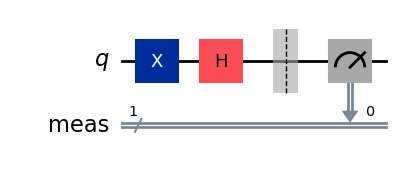

In [12]:
# Create a quantum circuit with 1 qubit.
test = QuantumCircuit(1)

# Apply an X gate (Pauli-X) to flip the qubit.
test.x(0)

# Apply a Hadamard gate to the qubit.
test.h(0)

# Measure the qubit.
test.measure_all()

# Draw the quantum circuit.
test.draw('mpl')

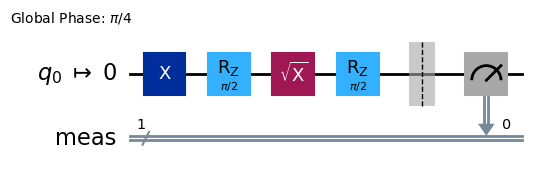

In [13]:
# Transpile the test circuit for the IBM backend with no optimization.
test_transpiled = transpile(test, backend=backend_ibm, optimization_level=0)

# Draw the transpiled circuit, hiding idle wires.
test_transpiled.draw('mpl', idle_wires=False)

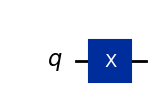

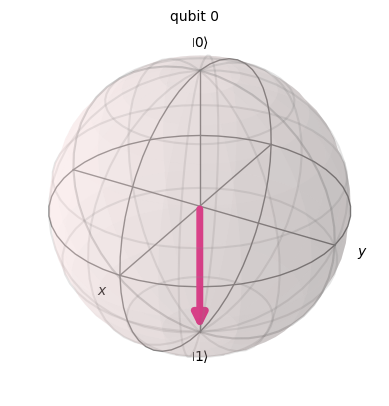

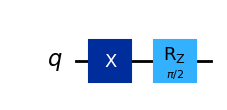

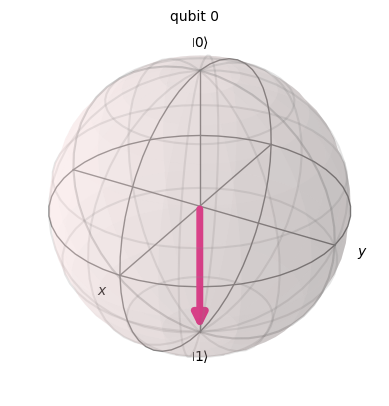

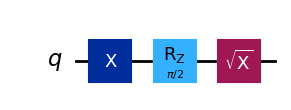

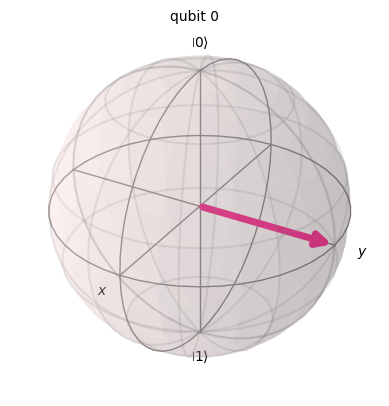

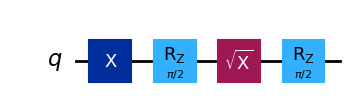

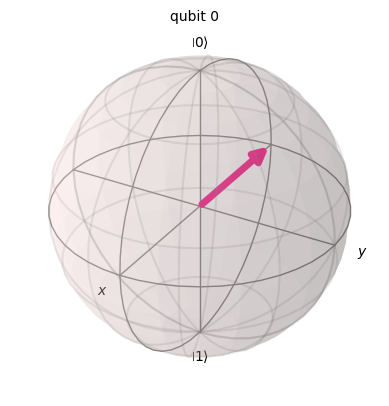

In [14]:
# Create a quantum circuit with 1 qubit.
test = QuantumCircuit(1)

# Apply an X gate (Pauli-X) to flip the qubit.
test.x(0)
visualization(test)  # Visualize the circuit and its state.

# Apply an RZ rotation of π/2 to the qubit.
test.rz(pi/2, 0)
visualization(test)  # Visualize the updated circuit and state.

# Apply an SX (square-root of X) gate to the qubit.
test.sx(0)
visualization(test)  # Visualize the updated circuit and state.

# Apply another RZ rotation of π/2 to the qubit.
test.rz(pi/2, 0)
visualization(test)  # Final visualization.

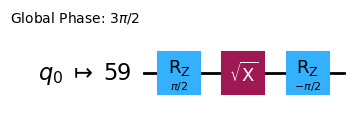

In [15]:
# Transpile the 'test' circuit for the IBM backend with default optimization.
test_transpiled = transpile(test, backend=backend_ibm)

# Draw the transpiled circuit, hiding idle wires.
test_transpiled.draw('mpl', idle_wires=False)

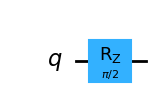

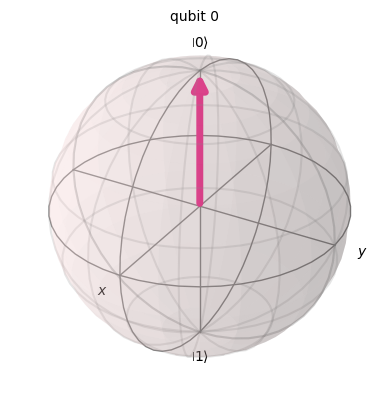

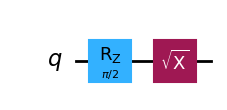

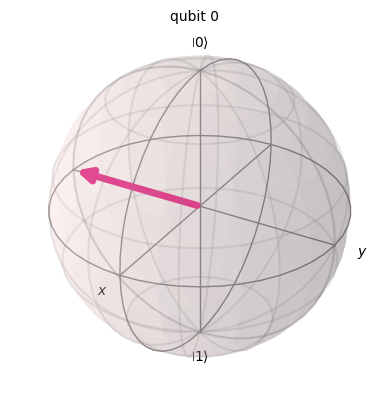

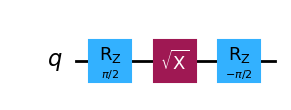

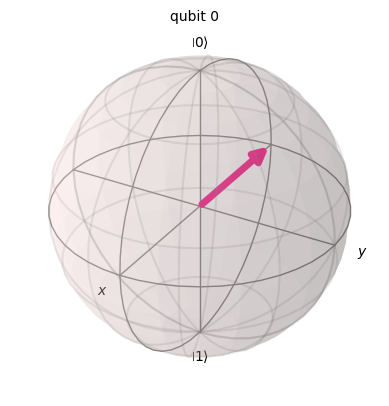

In [16]:
# Create a quantum circuit with 1 qubit.
test = QuantumCircuit(1)

# Apply an RZ rotation of π/2 to the qubit.
test.rz(pi/2, 0)
visualization(test)  # Visualize the circuit and its state.

# Apply an SX (square-root of X) gate to the qubit.
test.sx(0)
visualization(test)  # Visualize the updated circuit and state.

# Apply an RZ rotation of -π/2 to the qubit.
test.rz(-pi/2, 0)
visualization(test)  # Final visualization.

### PUB(Primitive Unified Blocs) preparation

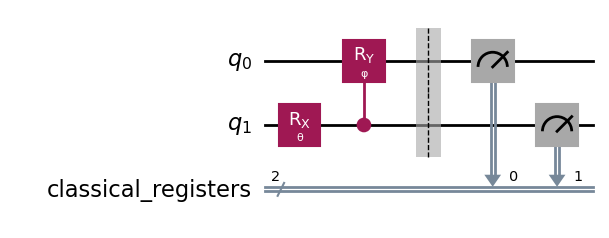

In [17]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter

# Define parameters for the quantum circuit.
theta = Parameter('θ')
phi = Parameter('φ')

# Create quantum and classical registers.
qr = QuantumRegister(2, name='q')
cr = ClassicalRegister(2, name='classical_registers')

# Initialize a quantum circuit with the registers.
qc2 = QuantumCircuit(qr, cr)

# Apply an RX rotation with parameter theta to qubit 1.
qc2.rx(theta, 1)

# Apply a CRY gate with parameter phi between qubits 1 and 0.
qc2.cry(phi, 1, 0)

# Add a barrier to separate the gates from the measurements.
qc2.barrier()

# Measure the quantum bits into the classical bits.
qc2.measure(qr, cr)

# Draw the quantum circuit.
qc2.draw('mpl')

In [18]:
# Display the parameters used in the quantum circuit.
print(qc2.parameters)

ParameterView([Parameter(θ), Parameter(φ)])


angels = $
[[\theta_0, \phi_0], [\theta_1, \phi_1], [\theta_2, \phi_2], …]
$

In [19]:
# Define a list of angles, each as a pair [theta, phi].
angles = [[pi/4, pi/2], [pi/3, pi], [pi/2, 2*pi]]

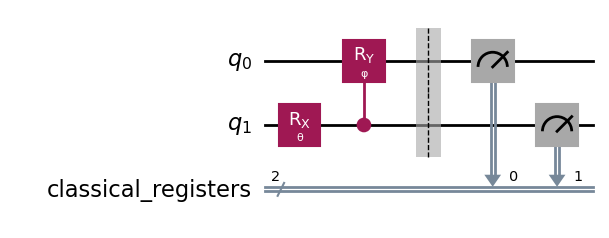

In [20]:
# Transpile the quantum circuit for the Aer backend.
qc2_aer = transpile(qc2, backend=backend_aer)

# Draw the transpiled circuit.
qc2_aer.draw('mpl')

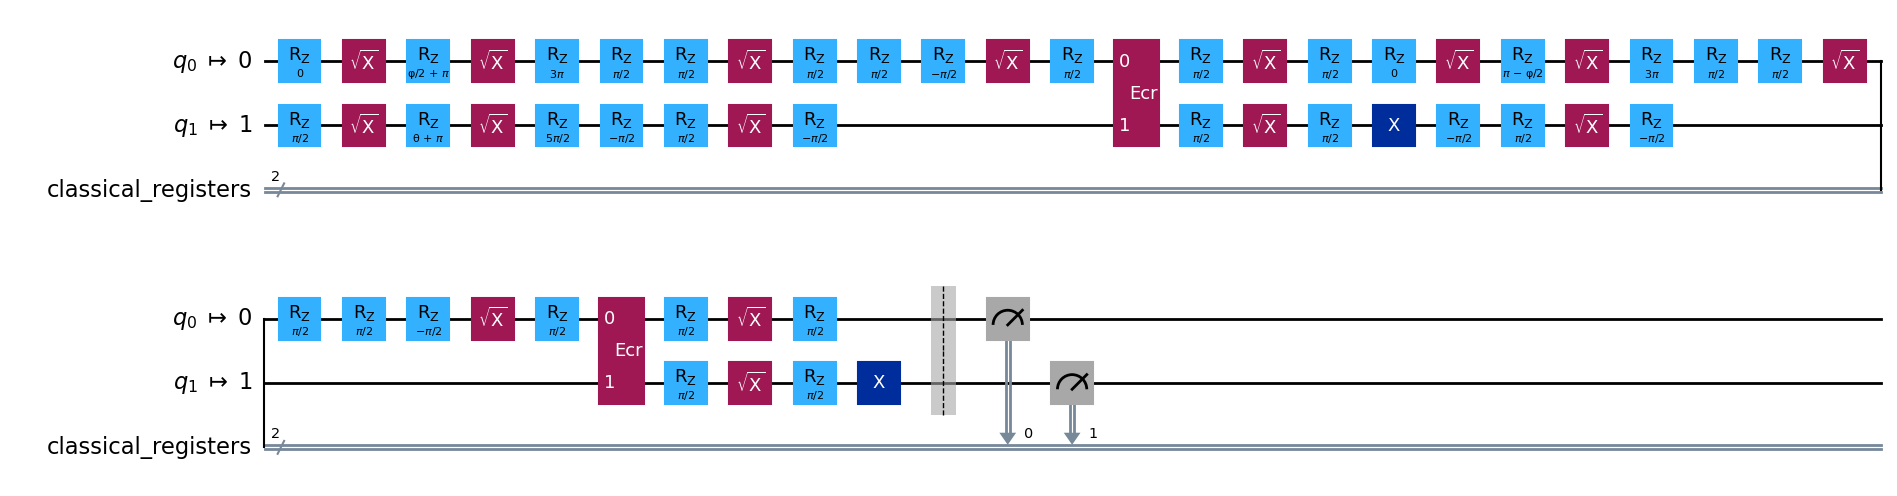

In [21]:
# Transpile the quantum circuit for the IBM backend with no optimization.
qc2_ibm = transpile(qc2, backend=backend_ibm, optimization_level=0)

# Draw the transpiled circuit, hiding idle wires.
qc2_ibm.draw('mpl', idle_wires=False)

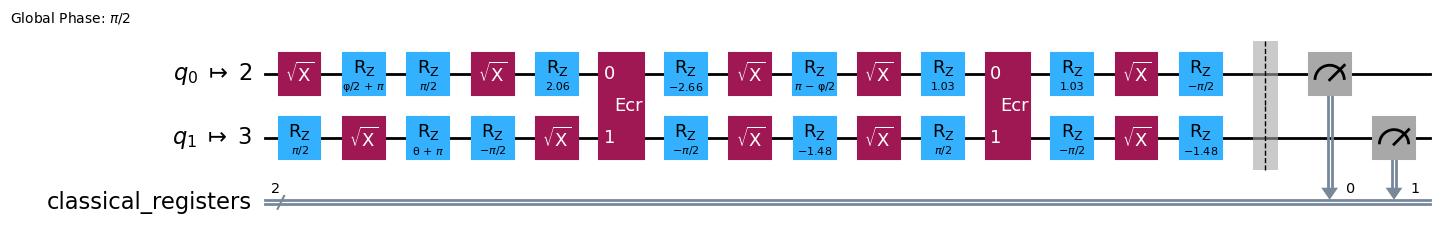

In [22]:
# Transpile the quantum circuit for the IBM backend with default optimization.
qc2_ibm = transpile(qc2, backend=backend_ibm)

# Draw the transpiled circuit, hiding idle wires.
qc2_ibm.draw('mpl', idle_wires=False)

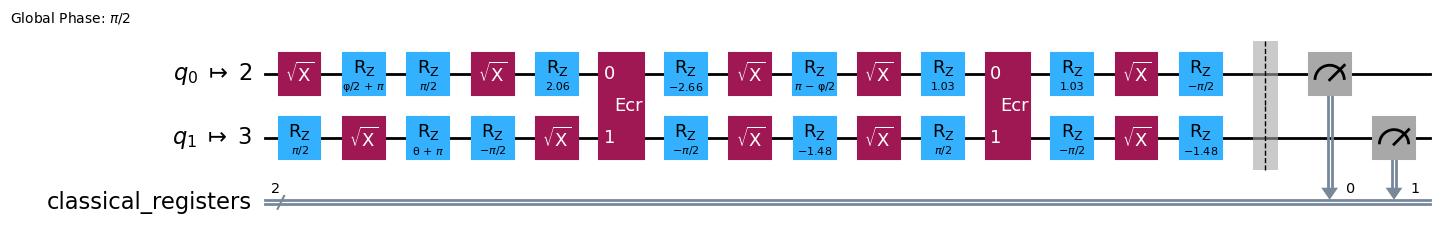

In [23]:
# Transpile the quantum circuit for the IBM backend with maximum optimization level (3).
qc2_ibm = transpile(qc2, backend=backend_ibm, optimization_level=3)

# Draw the transpiled circuit, hiding idle wires.
qc2_ibm.draw('mpl', idle_wires=False)

optimization_level (Optional[int])

How much optimization to perform on the circuits. Higher levels generate more optimized circuits, at the expense of longer transpilation time.

* 0: no optimization
* 1: light optimization
* 2: heavy optimization
* 3: even heavier optimization

If None, level 1 will be chosen as default.

### QPU's results

In [ ]:
# Run the sampler on the Aer backend with specific shots for each circuit.
job_aer = sampler_aer.run([(qc1_aer, None, 100), (qc2_aer, angles, 1000)])

# Run the sampler on the IBM backend with specific shots for each circuit.
job_ibm = sampler_ibm.run([(qc1_ibm, None, 100), (qc2_ibm, angles, 1000)])

CPU times: user 236 ms, sys: 17.8 ms, total: 254 ms
Wall time: 3.13 s


In [ ]:
# Retrieve the results from the Aer backend job.
result_aer = job_aer.result()

# Retrieve the results from the IBM backend job.
result_ibm = job_ibm.result()

In [ ]:
# Extract the measurement counts for the first circuit (qc1_aer) from the Aer backend results.
counts_qc1_aer = result_aer[0].data.meas.get_counts()

# Extract the measurement counts for the first circuit (qc1_ibm) from the IBM backend results.
counts_qc1_ibm = result_ibm[0].data.meas.get_counts()

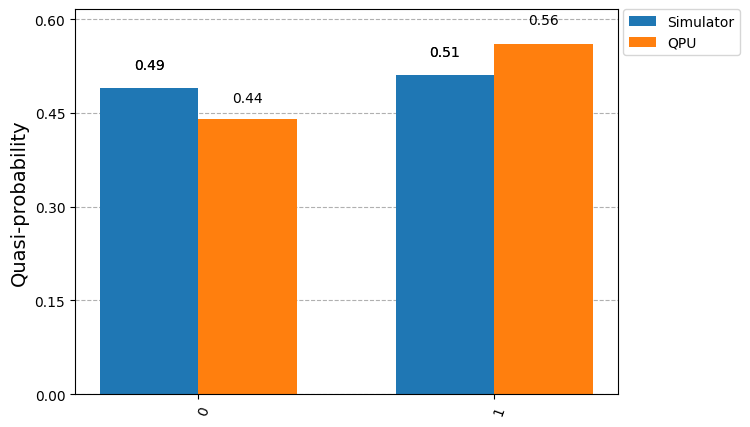

In [ ]:
# Plot the distribution of measurement counts for both the Aer simulator and the IBM QPU results.
plot_distribution([counts_qc1_aer, counts_qc1_ibm], legend=['Simulator', 'QPU'])

In [ ]:
# Extract the measurement counts for the second circuit (qc2_aer) from the Aer backend results.
counts_qc2_aer = result_aer[1].data.classical_registers.get_counts()

# Extract the measurement counts for the second circuit (qc2_ibm) from the IBM backend results.
counts_qc2_ibm = result_ibm[1].data.classical_registers.get_counts()

In [ ]:
# Print the measurement counts for the second circuit from both the Aer simulator and the IBM QPU.
print(f'Aer: {counts_qc2_aer}')
print(f'IBM: {counts_qc2_ibm}')

Aer: {'00': 2123, '10': 66, '11': 811}
IBM: {'01': 16, '00': 2006, '10': 93, '11': 885}


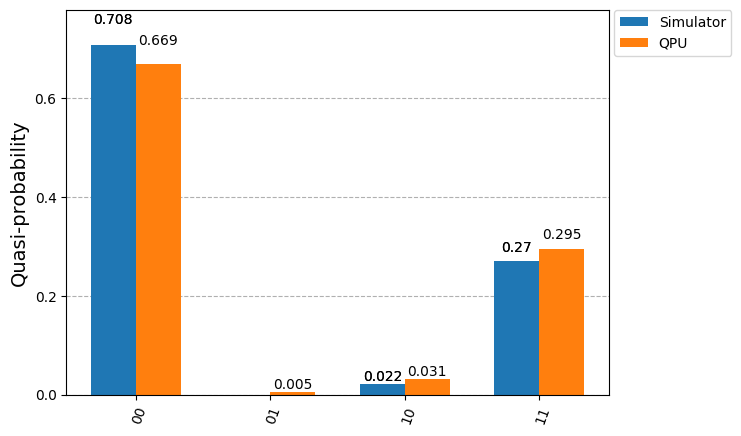

In [ ]:
# Plot the distribution of measurement counts for the second circuit from both the Aer simulator and the IBM QPU.
plot_distribution([counts_qc2_aer, counts_qc2_ibm], legend=['Simulator', 'QPU'])

Aer: {'00': 873, '10': 66, '11': 61}
IBM: {'01': 3, '00': 829, '10': 82, '11': 86}


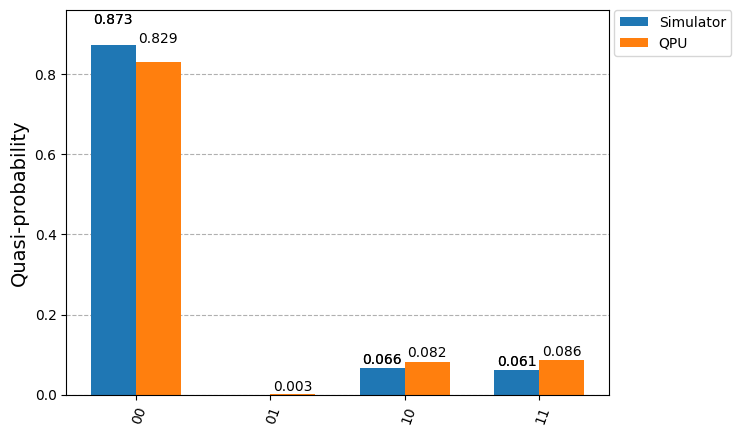

Aer: {'11': 251, '00': 749}
IBM: {'11': 258, '00': 728, '01': 8, '10': 6}


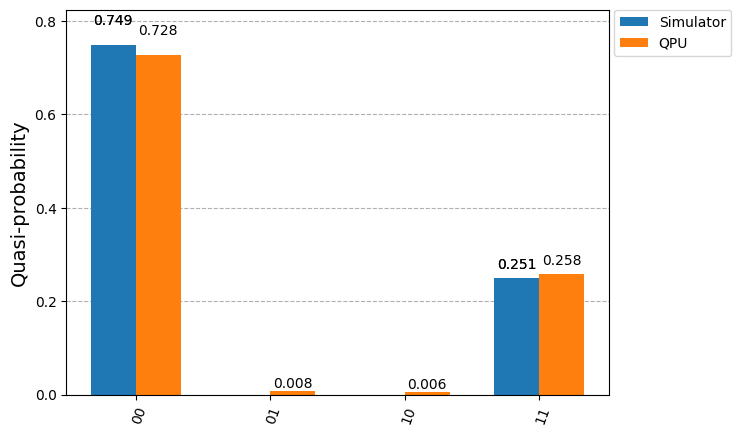

Aer: {'11': 499, '00': 501}
IBM: {'00': 449, '11': 541, '10': 5, '01': 5}


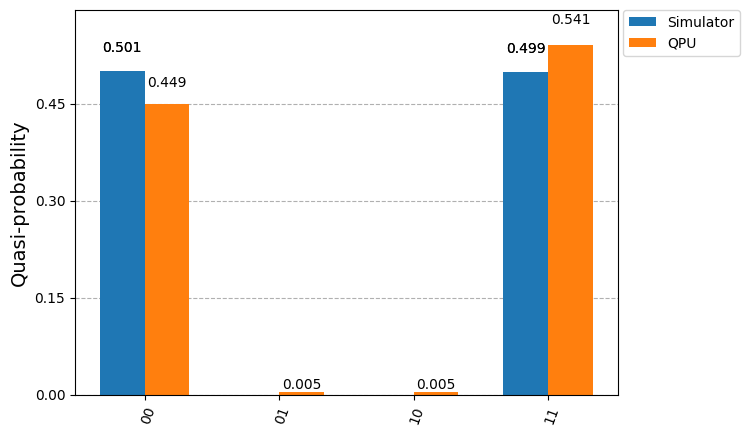

In [ ]:
# Iterate over each angle in the angles list and print and plot the measurement counts for each.
for i in range(len(angles)):
    # Get measurement counts for the i-th angle from both Aer and IBM results.
    counts_qc2_aer = result_aer[1].data.classical_registers.get_counts(i)
    counts_qc2_ibm = result_ibm[1].data.classical_registers.get_counts(i)

    # Print the counts from the Aer simulator and IBM QPU for the current angle.
    print(f'Aer: {counts_qc2_aer}')
    print(f'IBM: {counts_qc2_ibm}')

    # Display the plot of measurement counts for the current angle.
    display(plot_distribution([counts_qc2_aer, counts_qc2_ibm], legend=['Simulator', 'QPU']))

## Retrive results

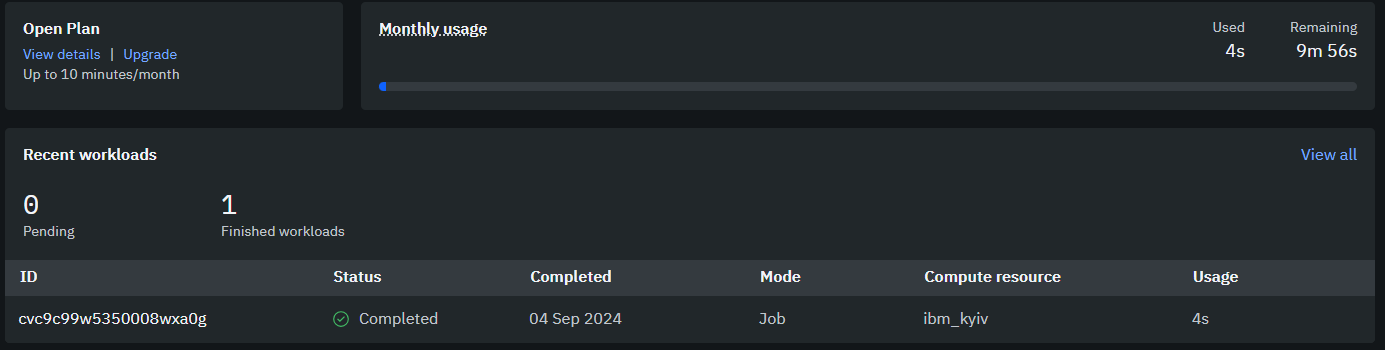

In [ ]:
# Save the IBM Quantum account credentials for future use.
service.save_account(my_token, channel="ibm_quantum")

In [ ]:
# Retrieve a previously saved job using its job ID.
job_saved = QiskitRuntimeService().job('cvm7wa1z17rg008drc9g')

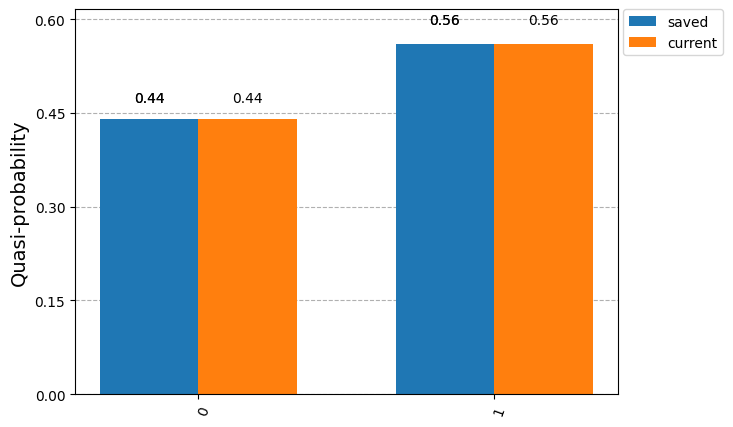

saved: {'01': 16, '00': 2006, '10': 93, '11': 885}
current: {'01': 16, '00': 2006, '10': 93, '11': 885}
Aggregate


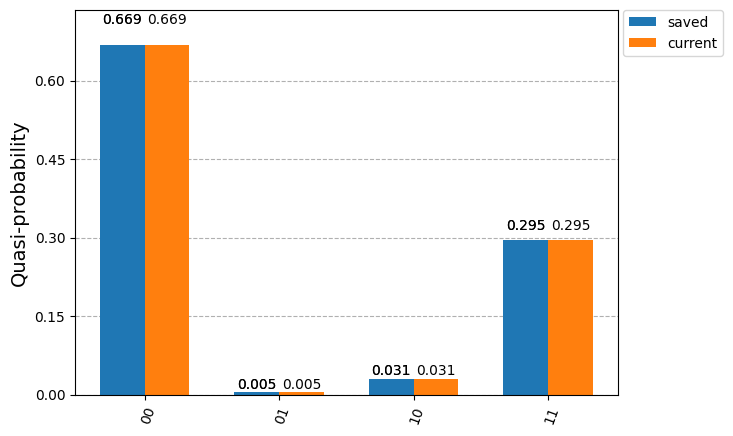

saved: {'01': 3, '00': 829, '10': 82, '11': 86}
current: {'01': 3, '00': 829, '10': 82, '11': 86}


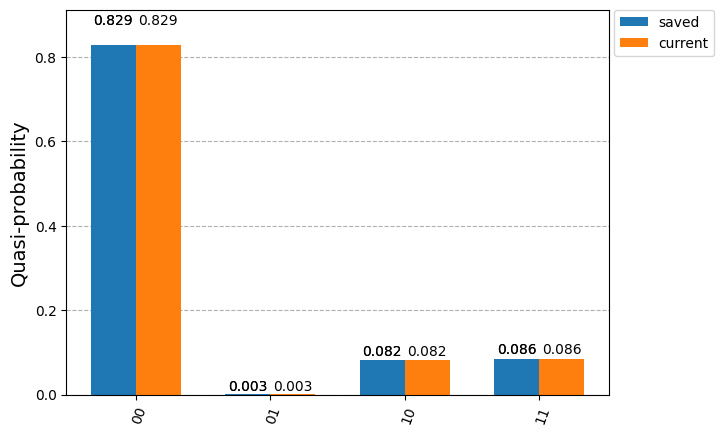

saved: {'11': 258, '00': 728, '01': 8, '10': 6}
current: {'11': 258, '00': 728, '01': 8, '10': 6}


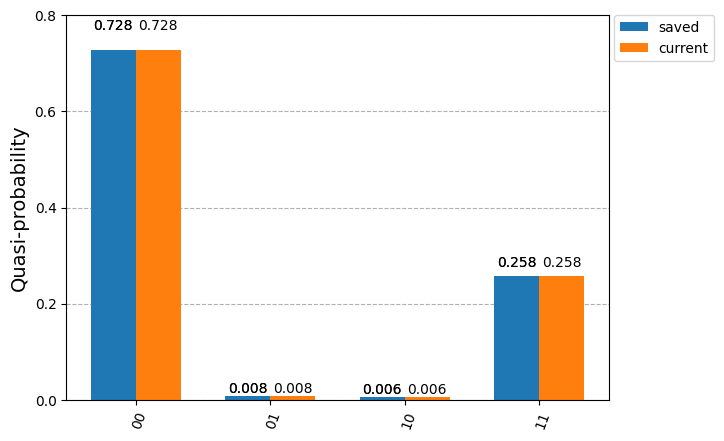

saved: {'00': 449, '11': 541, '10': 5, '01': 5}
current: {'00': 449, '11': 541, '10': 5, '01': 5}


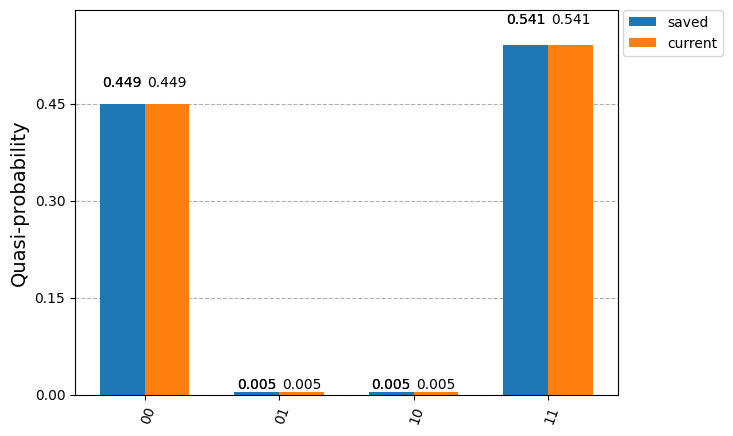

In [ ]:
# Retrieve the result of the previously saved job.
saved_result = job_saved.result()

# Extract and plot the measurement counts for the first circuit from the saved result and the current IBM result.
saved_counts_qc1 = saved_result[0].data.meas.get_counts()
display(plot_distribution([saved_counts_qc1, counts_qc1_ibm], legend=['saved', 'current']))

# Extract and print the measurement counts for the second circuit from both the saved result and the current IBM result.
saved_counts_qc2 = saved_result[1].data.classical_registers.get_counts()
counts_qc2_ibm = result_ibm[1].data.classical_registers.get_counts()
print(f'saved: {saved_counts_qc2}')
print(f'current: {counts_qc2_ibm}')

# Plot the aggregated measurement counts for the second circuit.
print("Aggregate")
display(plot_distribution([saved_counts_qc2, counts_qc2_ibm], legend=['saved', 'current']))

# Iterate over each angle, comparing saved and current counts for each angle.
for i in range(len(angles)):
    counts_qc2_saved = saved_result[1].data.classical_registers.get_counts(i)
    counts_qc2_ibm = result_ibm[1].data.classical_registers.get_counts(i)
    print(f'saved: {counts_qc2_saved}')
    print(f'current: {counts_qc2_ibm}')
    display(plot_distribution([counts_qc2_saved, counts_qc2_ibm], legend=['saved', 'current']))

## Estimator

In [25]:
# Initialize EstimatorV2 for the Aer simulator backend.
estimator_aer = EstimatorV2(mode=backend_aer)

# Initialize EstimatorV2 for the IBM Quantum backend.
estimator_ibm = EstimatorV2(mode=backend_ibm)

In [26]:
# Define a list of observables for a two-qubit system.
# Each observable is represented by SparsePauliOps with specific Pauli operators and coefficients.
obsv_list = [[SparsePauliOp(["XX", "IY"], [0.5, 0.5])],
             [SparsePauliOp(["XX"], [1])],
             [SparsePauliOp(["IY"], [1])]]

**Map observables to backend layout**

In [27]:
# Obtain the layout of the quantum circuit for IBM backend.
layout = qc2_ibm.layout

# Prepare observables for the IBM backend by applying the layout to each observable.
# This ensures the observables match the qubit mapping of the backend.
obsv_ibm = []
for obsv in obsv_list:
#  print(obsv[0], obsv)
  obsv_temp = obsv[0].apply_layout(layout)  # Apply the layout to the observable
  print(obsv_temp)  # Print the adjusted observable
  obsv_ibm.append([obsv_temp])  # Append the adjusted observable to the list

SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXXII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYII'],
              coeffs=[0.5+0.j, 0.5+0.j])
SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXXII'],
              coeffs=[1.+0.j])
SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYII'],
              coeffs=[1.+0.j])


In [28]:
layout

TranspileLayout(initial_layout=Layout({
3: Qubit(QuantumRegister(2, 'q'), 1),
2: Qubit(QuantumRegister(2, 'q'), 0),
0: Qubit(QuantumRegister(125, 'ancilla'), 0),
1: Qubit(QuantumRegister(125, 'ancilla'), 1),
4: Qubit(QuantumRegister(125, 'ancilla'), 2),
5: Qubit(QuantumRegister(125, 'ancilla'), 3),
6: Qubit(QuantumRegister(125, 'ancilla'), 4),
7: Qubit(QuantumRegister(125, 'ancilla'), 5),
8: Qubit(QuantumRegister(125, 'ancilla'), 6),
9: Qubit(QuantumRegister(125, 'ancilla'), 7),
10: Qubit(QuantumRegister(125, 'ancilla'), 8),
11: Qubit(QuantumRegister(125, 'ancilla'), 9),
12: Qubit(QuantumRegister(125, 'ancilla'), 10),
13: Qubit(QuantumRegister(125, 'ancilla'), 11),
14: Qubit(QuantumRegister(125, 'ancilla'), 12),
15: Qubit(QuantumRegister(125, 'ancilla'), 13),
16: Qubit(QuantumRegister(125, 'ancilla'), 14),
17: Qubit(QuantumRegister(125, 'ancilla'), 15),
18: Qubit(QuantumRegister(125, 'ancilla'), 16),
19: Qubit(QuantumRegister(125, 'ancilla'), 17),
20: Qubit(QuantumRegister(125, 'ancill

In [ ]:
# Run the estimator on the Aer backend with the quantum circuit, list of observables, angles, and a noise parameter.
# No need to map observables for Aer as it's a simulator.
job2_aer = estimator_aer.run([(qc2_aer, obsv_list, angles, 0.01)])

# Run the estimator on the IBM backend with the quantum circuit, mapped observables, angles, and a noise parameter.
job2_ibm = estimator_ibm.run([(qc2_ibm, obsv_ibm, angles, 0.01)])

In [ ]:
# Extract expectation values from the results of the estimators
exp_vals_aer = job2_aer.result()[0].data.evs  # Expectation values from Aer
exp_vals_ibm = job2_ibm.result()[0].data.evs  # Expectation values from IBM

# Print the expectation values for comparison
print(f"Expectation values of Aer: \n{exp_vals_aer}")
print(f"Expectation values of IBM: \n{exp_vals_ibm}")

Expectation values of Aer: 
[[ 0.0011  0.0173  0.0174]
 [-0.004   0.0014 -0.0018]
 [ 0.0062  0.0332  0.0366]]
Expectation values of IBM: 
[[-0.01535237  0.01760398  0.02715142]
 [-0.02003834  0.037623    0.04886901]
 [-0.0106664  -0.00241503  0.00543383]]


3 lists because of 3 observables

each lists 3 expectation value because of 3 angels

## Session

There are 3 ways to execute in `Runtime`

1. **Job:** (Simple execution)
2. **Session:** (Hybrid CPU and QPU execution)
3. **Batch:** (Parallel execution)

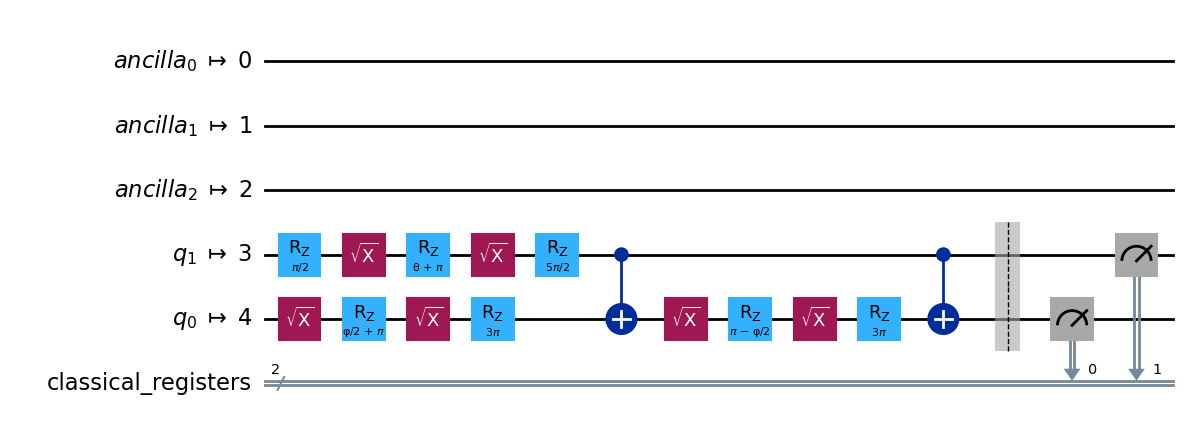

In [30]:
from qiskit_ibm_runtime import Session
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

fake_backend = FakeManilaV2()
FakeSim_qc2 = transpile(qc2, backend=fake_backend)
FakeSim_qc2.draw('mpl')

In [32]:
FakeSim_obsv = [[obsv[0].apply_layout(FakeSim_qc2.layout)] for obsv in obsv_list]
print(FakeSim_obsv)

[[SparsePauliOp(['XXIII', 'YIIII'],
              coeffs=[0.5+0.j, 0.5+0.j])], [SparsePauliOp(['XXIII'],
              coeffs=[1.+0.j])], [SparsePauliOp(['YIIII'],
              coeffs=[1.+0.j])]]


In [35]:
# Context manager
with Session(# service = QiskitRunTimeService(),
    backend=fake_backend) as session:
    estimator = EstimatorV2(mode=session)
    results = estimator.run([(FakeSim_qc2, FakeSim_obsv, angles, 0.01)]).result()[0]
    print(f"Expection values: \n {results.data.evs}")

Expection values: 
 [[ 0.0047  0.0114  0.0177]
 [-0.0032  0.012   0.0114]
 [ 0.0126  0.0108  0.024 ]]
